In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image, ImageFilter
from diffusers import StableDiffusionInpaintPipeline


Image.MAX_IMAGE_PIXELS = None
PROJECT_ROOT = Path("/home/irdorat/ML_comp")
ORIGINAL_PATH = PROJECT_ROOT / "data/test/01-PAN-20240420-113-325-L00000010882-CCD3_5_crop7.jpg"
MODEL_PATH = (
    PROJECT_ROOT / "models/pretrained/huggingface-cache"
    / "models--stable-diffusion-v1-5--stable-diffusion-inpainting"
    / "snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb"
)

# Main user setting. It must be divisible by 8 and at least as large as source.
CANVAS_SIZE = 2048
OUTPUT_PATH = PROJECT_ROOT / f"data/test/global_guide_outpaint_{CANVAS_SIZE}x{CANVAS_SIZE}.png"
SEED = 42

GUIDE_SIZE = 768

TILE_SIZE = 512
TILE_OVERLAP = 256
TILE_STEP = 256

GUIDE_STRENGTH = 0.82
REFINE_STRENGTH = 0.18

# Refinement contributes texture only. Per-tile illumination and large blobs are
# removed before overlap-add so they cannot form visible rectangular regions.
DETAIL_BLUR_RADIUS = 18
DETAIL_LIMIT = 10.0
DETAIL_GAIN = 0.70

GUIDE_STEPS = 60
REFINE_STEPS = 40
GUIDANCE_SCALE = 4.0

if CANVAS_SIZE % 8 != 0:
    raise ValueError("CANVAS_SIZE must be divisible by 8")
if GUIDE_SIZE % 8 != 0 or TILE_SIZE % 8 != 0 or TILE_STEP % 8 != 0:
    raise ValueError("GUIDE_SIZE, TILE_SIZE and TILE_STEP must be divisible by 8")
if not 0 < TILE_OVERLAP < TILE_SIZE:
    raise ValueError("TILE_OVERLAP must be between 1 and TILE_SIZE - 1")

print("Canvas:", CANVAS_SIZE)
print("Guide:", GUIDE_SIZE)
print("Tile/overlap/step:", TILE_SIZE, TILE_OVERLAP, TILE_STEP)
print("Output:", OUTPUT_PATH)

Canvas: 2048
Guide: 768
Tile/overlap/step: 512 256 256
Output: /home/irdorat/ML_comp/data/test/global_guide_outpaint_2048x2048.png


In [3]:
if not ORIGINAL_PATH.is_file():
    raise FileNotFoundError(ORIGINAL_PATH)

with Image.open(ORIGINAL_PATH) as source:
    original_image = source.convert("RGB").copy()

original_pixels = np.asarray(original_image).copy()
original_width, original_height = original_image.size
if original_width > CANVAS_SIZE or original_height > CANVAS_SIZE:
    raise ValueError("CANVAS_SIZE is smaller than the source image")

# Preserve the placement used by the previous notebook: source at upper right.
offset_x = CANVAS_SIZE - original_width
offset_y = 0
source_box = (
    offset_x,
    offset_y,
    offset_x + original_width,
    offset_y + original_height,
)

print("Original:", original_image.size)
print("Original position:", (offset_x, offset_y))
print("Unknown left/bottom:", offset_x, CANVAS_SIZE - original_height)

Original: (828, 828)
Original position: (1220, 0)
Unknown left/bottom: 1220 1220


In [4]:
if not MODEL_PATH.is_dir():
    raise FileNotFoundError(MODEL_PATH)
if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required")

pipe = StableDiffusionInpaintPipeline.from_pretrained(
    MODEL_PATH,
    variant="fp16",
    torch_dtype=torch.float16,
    use_safetensors=True,
    local_files_only=True,
    safety_checker=None,
    requires_safety_checker=False,
)
pipe.enable_model_cpu_offload()
pipe.vae.enable_tiling()
pipe.set_progress_bar_config(disable=False)

scene_prompt = (
    "panchromatic satellite photograph, strict vertical nadir view, "
    "small industrial coast confined to the upper right, "
    "land ends naturally near the source boundary, "
    "mostly medium-gray open sea, visible natural wave texture, "
    "balanced exposure, visible shadow detail, consistent illumination, "
    "realistic satellite scale, broad grayscale tonal range"
)

negative_prompt = (
    "large continent, mountains, island, city, new harbor, new ship, "
    "diagonal line, cable, pipeline, extended pier, circular arc, "
    "geometric shape, collage, tiles, grid, rectangular regions, hard seams, "
    "text, map, color, horizon, underexposed, crushed blacks, blank darkness"
)

for name, prompt in {"scene": scene_prompt, "negative": negative_prompt}.items():
    count = len(pipe.tokenizer(prompt, truncation=False).input_ids)
    print(f"{name}: {count}/{pipe.tokenizer.model_max_length} tokens")
    if count > pipe.tokenizer.model_max_length:
        raise ValueError(f"{name} prompt exceeds tokenizer limit")

Loading pipeline components...: 100%|██████████| 6/6 [00:00<00:00,  7.38it/s]


scene: 62/77 tokens
negative: 64/77 tokens


100%|██████████| 49/49 [00:18<00:00,  2.68it/s]


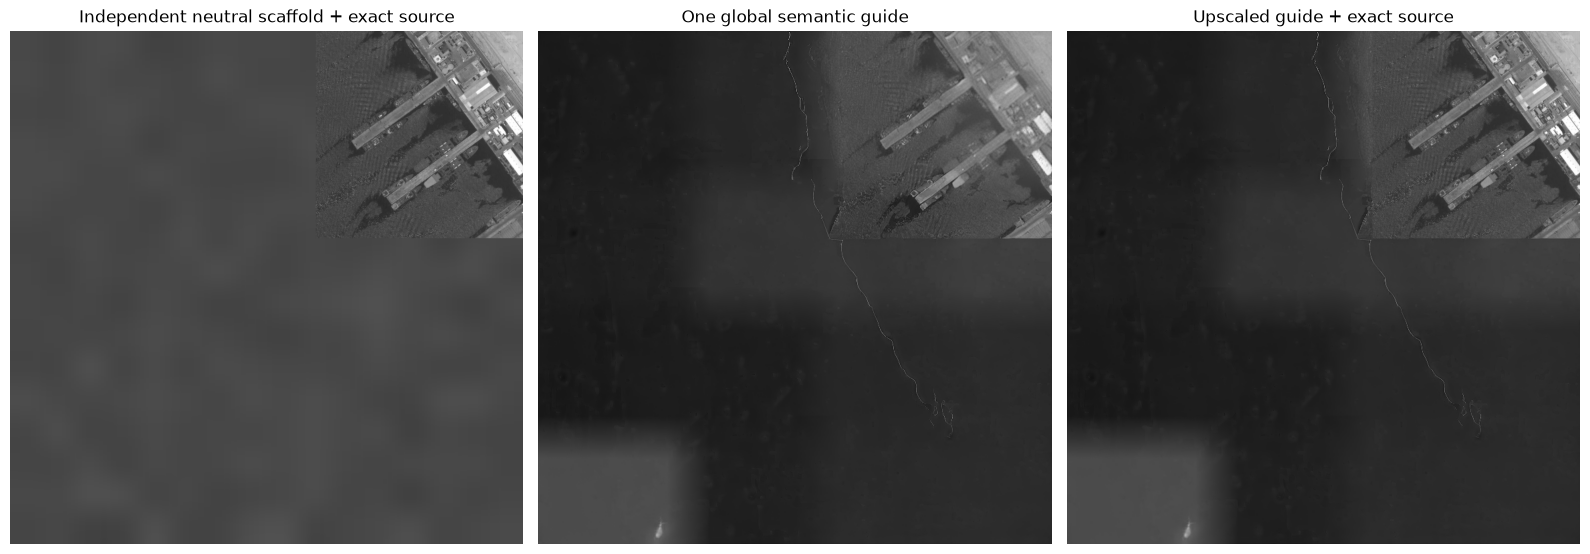

In [5]:
def make_semantic_scaffold(
    source,
    size,
    offset_x,
    offset_y,
    seed=42,
    neutral_level=48,
):
    """Use no source-derived pixels outside the exact protected source.

    The exterior is independent neutral low-frequency noise. Semantic continuation
    must therefore be inferred by the model from the source itself and the prompt.
    """
    rng = np.random.default_rng(seed)

    # Generate low-resolution random illumination and upscale it smoothly. This
    # avoids straight scaffold lines without prescribing water or land geometry.
    coarse_size = max(8, size // 128)
    coarse = rng.normal(
        loc=float(neutral_level),
        scale=3.0,
        size=(coarse_size, coarse_size),
    )
    coarse = np.clip(coarse, 0, 255).astype(np.uint8)
    background = Image.fromarray(coarse, mode="L").resize(
        (size, size),
        Image.Resampling.BICUBIC,
    ).filter(ImageFilter.GaussianBlur(radius=8))
    canvas = np.repeat(np.asarray(background)[..., None], 3, axis=2).copy()

    source_array = np.asarray(source)
    height, width, _ = source_array.shape
    canvas[offset_y:offset_y + height, offset_x:offset_x + width] = source_array
    return Image.fromarray(canvas, mode="RGB")

def source_protection_mask(size, source_box):
    """White exterior is generated; black source rectangle is protected."""
    mask = Image.new("L", (size, size), 255)
    left, top, right, bottom = source_box
    mask.paste(0, (left, top, right, bottom))
    return mask


scaffold = make_semantic_scaffold(
    original_image,
    CANVAS_SIZE,
    offset_x,
    offset_y,
    seed=SEED,
    neutral_level=72,
)
full_mask = source_protection_mask(CANVAS_SIZE, source_box)

# One model call sees the complete future image and establishes global geography.
guide_image = scaffold.resize((GUIDE_SIZE, GUIDE_SIZE), Image.Resampling.LANCZOS)
guide_mask = full_mask.resize((GUIDE_SIZE, GUIDE_SIZE), Image.Resampling.NEAREST)
guide_generator = torch.Generator(device="cpu").manual_seed(SEED)

with torch.inference_mode():
    global_guide_small = pipe(
        prompt=scene_prompt,
        negative_prompt=negative_prompt,
        image=guide_image,
        mask_image=guide_mask,
        width=GUIDE_SIZE,
        height=GUIDE_SIZE,
        strength=GUIDE_STRENGTH,
        num_inference_steps=GUIDE_STEPS,
        guidance_scale=GUIDANCE_SCALE,
        generator=guide_generator,
    ).images[0].convert("L").convert("RGB")

global_guide = global_guide_small.resize(
    (CANVAS_SIZE, CANVAS_SIZE),
    Image.Resampling.LANCZOS,
)
global_guide.paste(original_image, (offset_x, offset_y))

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
axes[0].imshow(scaffold)
axes[0].set_title("Independent neutral scaffold + exact source")
axes[1].imshow(global_guide_small)
axes[1].set_title("One global semantic guide")
axes[2].imshow(global_guide)
axes[2].set_title("Upscaled guide + exact source")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

In [6]:
def tile_starts(length, tile_size, step):
    """Cover an axis fully while keeping every tile aligned to 8 pixels."""
    if length <= tile_size:
        return [0]
    starts = list(range(0, length - tile_size + 1, step))
    last = length - tile_size
    if starts[-1] != last:
        starts.append(last)
    if any(value % 8 != 0 for value in starts):
        raise ValueError("All tile starts must be divisible by 8")
    return starts


def cosine_window(size, edge_floor=0.03):
    """Positive 2-D window for overlap-add without division by zero."""
    axis = np.hanning(size).astype(np.float32)
    axis = edge_floor + (1.0 - edge_floor) * axis
    return np.outer(axis, axis).astype(np.float32)


x_starts = tile_starts(CANVAS_SIZE, TILE_SIZE, TILE_STEP)
y_starts = tile_starts(CANVAS_SIZE, TILE_SIZE, TILE_STEP)
tile_boxes = [
    (x, y, x + TILE_SIZE, y + TILE_SIZE)
    for y in y_starts
    for x in x_starts
]

# The high-level inpainting pipeline must construct image_latent + noise itself
# when REFINE_STRENGTH < 1. Passing raw `latents=` here would start from pure
# noise but run only the shortened img2img schedule, leaving visible noise.
tile_window = cosine_window(TILE_SIZE)
accumulator = np.zeros((CANVAS_SIZE, CANVAS_SIZE, 3), dtype=np.float32)
weight_sum = np.zeros((CANVAS_SIZE, CANVAS_SIZE, 1), dtype=np.float32)

print("Tiles:", len(tile_boxes), "grid:", len(x_starts), "x", len(y_starts))

Tiles: 49 grid: 7 x 7


In [7]:
accumulator = np.zeros(
    (CANVAS_SIZE, CANVAS_SIZE, 3),
    dtype=np.float32,
)

square_accumulator = np.zeros(
    (CANVAS_SIZE, CANVAS_SIZE, 3),
    dtype=np.float32,
)

weight_sum = np.zeros(
    (CANVAS_SIZE, CANVAS_SIZE, 1),
    dtype=np.float32,
)

for tile_index, (left, top, right, bottom) in enumerate(tile_boxes):
    print(f"[{tile_index + 1}/{len(tile_boxes)}]", (left, top, right, bottom))

    tile_guide = global_guide.crop((left, top, right, bottom)).convert("RGB")
    tile_mask = full_mask.crop((left, top, right, bottom)).convert("L")

    # A small blur gives the model context near the exact source boundary. The
    # final overlap-add still excludes source pixels explicitly.
    model_mask = tile_mask.filter(ImageFilter.GaussianBlur(8))
    # Deterministic per-position generator. The pipeline combines this noise with
    # the encoded global-guide tile at the correct REFINE_STRENGTH timestep.
    tile_seed = SEED + 1000 + (top // 8) * (CANVAS_SIZE // 8) + left // 8
    tile_generator = torch.Generator(device="cpu").manual_seed(tile_seed)

    with torch.inference_mode():
        prediction = pipe(
            prompt=scene_prompt,
            negative_prompt=negative_prompt,
            image=tile_guide,
            mask_image=model_mask,
            width=TILE_SIZE,
            height=TILE_SIZE,
            strength=REFINE_STRENGTH,
            num_inference_steps=REFINE_STEPS,
            guidance_scale=GUIDANCE_SCALE,
            generator=tile_generator,
        ).images[0].convert("L").convert("RGB")

    prediction_array = np.asarray(prediction).astype(np.float32)
    exterior = (np.asarray(tile_mask).astype(np.float32) / 255.0)[..., None]
    weights = tile_window[..., None] * exterior

    # Separate fine detail from each tile's incompatible low-frequency exposure.
    prediction_low = np.asarray(
        prediction.filter(ImageFilter.GaussianBlur(DETAIL_BLUR_RADIUS))
    ).astype(np.float32)
    detail_residual = prediction_array - prediction_low
    detail_residual = np.clip(detail_residual, -DETAIL_LIMIT, DETAIL_LIMIT)

    accumulator[top:bottom, left:right] += detail_residual * weights
    weight_sum[top:bottom, left:right] += weights

    square_accumulator[
        top:bottom,
        left:right,
    ] += (
        detail_residual ** 2
        * weights
    )

# Where no exterior prediction exists (the protected source), retain the guide;
# all exterior pixels are the weighted consensus of overlapping tile predictions.
guide_array = np.asarray(
    global_guide
).astype(np.float32)

refined_array = guide_array.copy()

valid = weight_sum[..., 0] > 1e-6

prediction_mean = np.zeros_like(
    accumulator
)

prediction_mean[valid] = (
    accumulator[valid]
    / weight_sum[valid]
)

prediction_square_mean = np.zeros_like(
    square_accumulator
)

prediction_square_mean[valid] = (
    square_accumulator[valid]
    / weight_sum[valid]
)

prediction_variance = np.maximum(
    prediction_square_mean
    - prediction_mean ** 2,
    0.0,
)

disagreement = np.mean(
    prediction_variance,
    axis=2,
)

# Если тайлы согласны, используем детализацию.
# Если сильно расходятся, сохраняем глобальный guide.
confidence = np.exp(
    -disagreement / 24.0
)

confidence = np.clip(
    confidence,
    0.25,
    1.0,
)

# Keep the coherent global guide as the base and add only agreed fine detail.
# Independent tile brightness and large-scale blobs never replace the guide.
refined_array[valid] = (
    guide_array[valid]
    + prediction_mean[valid]
    * confidence[valid, None]
    * DETAIL_GAIN
)

refined_array = np.clip(
    refined_array,
    0,
    255,
).astype(np.uint8)

refined_image = Image.fromarray(
    refined_array,
    mode="RGB",
)

print("Tiled refinement complete")

[1/49] (0, 0, 512, 512)


100%|██████████| 7/7 [00:01<00:00,  5.21it/s]


[2/49] (256, 0, 768, 512)


100%|██████████| 7/7 [00:01<00:00,  5.36it/s]


[3/49] (512, 0, 1024, 512)


...

[48/49] (1280, 1536, 1792, 2048)


100%|██████████| 7/7 [00:01<00:00,  5.18it/s]


[49/49] (1536, 1536, 2048, 2048)


100%|██████████| 7/7 [00:01<00:00,  5.04it/s]


Tiled refinement complete


In [8]:
def normalize_generated_exterior(
    image,
    source_box,
    target_mean=68.0,
    target_std=18.0,
):
    array = np.asarray(image).astype(np.float32).copy()

    height, width = array.shape[:2]
    left, top, right, bottom = source_box

    exterior_mask = np.ones(
        (height, width),
        dtype=bool,
    )

    # Область оригинала исключается из коррекции.
    exterior_mask[
        top:bottom,
        left:right,
    ] = False

    gray = (
        0.299 * array[..., 0]
        + 0.587 * array[..., 1]
        + 0.114 * array[..., 2]
    )

    values = gray[exterior_mask]

    current_mean = float(values.mean())
    current_std = max(
        float(values.std()),
        1.0,
    )

    gain = np.clip(
        target_std / current_std,
        0.7,
        1.5,
    )

    corrected = (
        (array - current_mean) * gain
        + target_mean
    )

    # Меняются только пиксели вне оригинала.
    array[exterior_mask] = corrected[exterior_mask]

    return Image.fromarray(
        np.clip(array, 0, 255).astype(np.uint8),
        mode="RGB",
    )

In [9]:
def smooth_vectors(
    values,
    radius=12,
):
    kernel = np.ones(
        2 * radius + 1,
        dtype=np.float32,
    )

    kernel /= kernel.sum()

    padded = np.pad(
        values,
        ((radius, radius), (0, 0)),
        mode="edge",
    )

    return np.stack(
        [
            np.convolve(
                padded[:, channel],
                kernel,
                mode="valid",
            )
            for channel in range(3)
        ],
        axis=1,
    )


def match_exterior_with_gray_distance(
    image,
    source,
    offset_x,
    offset_y,
    transition=256,
    far_mean=48.0,
):
    array = np.asarray(
        image
    ).astype(np.float32).copy()

    source_array = np.asarray(
        source
    ).astype(np.float32)

    source_height, source_width, _ = (
        source_array.shape
    )

    bottom_y = offset_y + source_height

    # Согласование левой внешней границы.
    if offset_x > 0:
        generated_edge = array[
            offset_y:bottom_y,
            offset_x - 1,
            :,
        ]

        source_edge = source_array[
            :,
            0,
            :,
        ]

        edge_delta = (
            source_edge
            - generated_edge
        )

        edge_delta = smooth_vectors(
            edge_delta,
            radius=20,
        )

        edge_delta = np.clip(
            edge_delta,
            -12.0,
            12.0,
        )

        correction_width = min(
            transition,
            offset_x,
        )

        for distance in range(
            correction_width
        ):
            x = offset_x - 1 - distance

            t = distance / max(
                correction_width - 1,
                1,
            )

            weight = 0.5 * (
                1.0
                + np.cos(np.pi * t)
            )

            array[
                offset_y:bottom_y,
                x,
                :,
            ] += edge_delta * weight

    # Согласование нижней внешней границы.
    if bottom_y < array.shape[0]:
        generated_edge = array[
            bottom_y,
            offset_x:offset_x + source_width,
            :,
        ]

        source_edge = source_array[
            -1,
            :,
            :,
        ]

        edge_delta = (
            source_edge
            - generated_edge
        )

        edge_delta = smooth_vectors(
            edge_delta,
            radius=20,
        )

        correction_height = min(
            transition,
            array.shape[0] - bottom_y,
        )

        for distance in range(
            correction_height
        ):
            y = bottom_y + distance

            t = distance / max(
                correction_height - 1,
                1,
            )

            weight = 0.5 * (
                1.0
                + np.cos(np.pi * t)
            )

            array[
                y,
                offset_x:offset_x + source_width,
                :,
            ] += edge_delta * weight

    # Маска пространства за пределами оригинала.
    exterior_mask = np.ones(
        array.shape[:2],
        dtype=bool,
    )

    exterior_mask[
        offset_y:bottom_y,
        offset_x:offset_x + source_width,
    ] = False

    # Ограниченный подъём слишком тёмных участков.
    gray = (
        0.299 * array[..., 0]
        + 0.587 * array[..., 1]
        + 0.114 * array[..., 2]
    )

    lift = np.maximum(
        far_mean - gray,
        0.0,
    )

    lift = np.minimum(
        lift,
        12.0,
    )

    array[exterior_mask] += lift[
        exterior_mask,
        None,
    ]

    result = Image.fromarray(
        np.clip(
            array,
            0,
            255,
        ).astype(np.uint8),
        mode="RGB",
    )

    result.paste(
        source,
        (offset_x, offset_y),
    )

    return result


pilot_result = match_exterior_with_gray_distance(
    image=refined_image,
    source=original_image,
    offset_x=offset_x,
    offset_y=offset_y,
    transition=96,
    far_mean=42.0,
)

# Повторное гарантированное восстановление оригинала.
pilot_result.paste(
    original_image,
    (offset_x, offset_y),
)

OUTPUT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

pilot_result.save(
    OUTPUT_PATH,
    format="PNG",
    compress_level=4,
)

with Image.open(OUTPUT_PATH) as saved:
    saved.load()

    restored = saved.convert(
        "RGB"
    ).crop(source_box)

restored_pixels = np.asarray(
    restored
)

difference = np.abs(
    restored_pixels.astype(np.int16)
    - original_pixels.astype(np.int16)
)

assert np.array_equal(
    restored_pixels,
    original_pixels,
), "Original pixels changed"

print("Saved:", OUTPUT_PATH)
print("Original pixels unchanged: True")
print(
    "Maximum difference:",
    int(difference.max()),
)

Saved: /home/irdorat/ML_comp/data/test/global_guide_outpaint_2048x2048.png
Original pixels unchanged: True
Maximum difference: 0


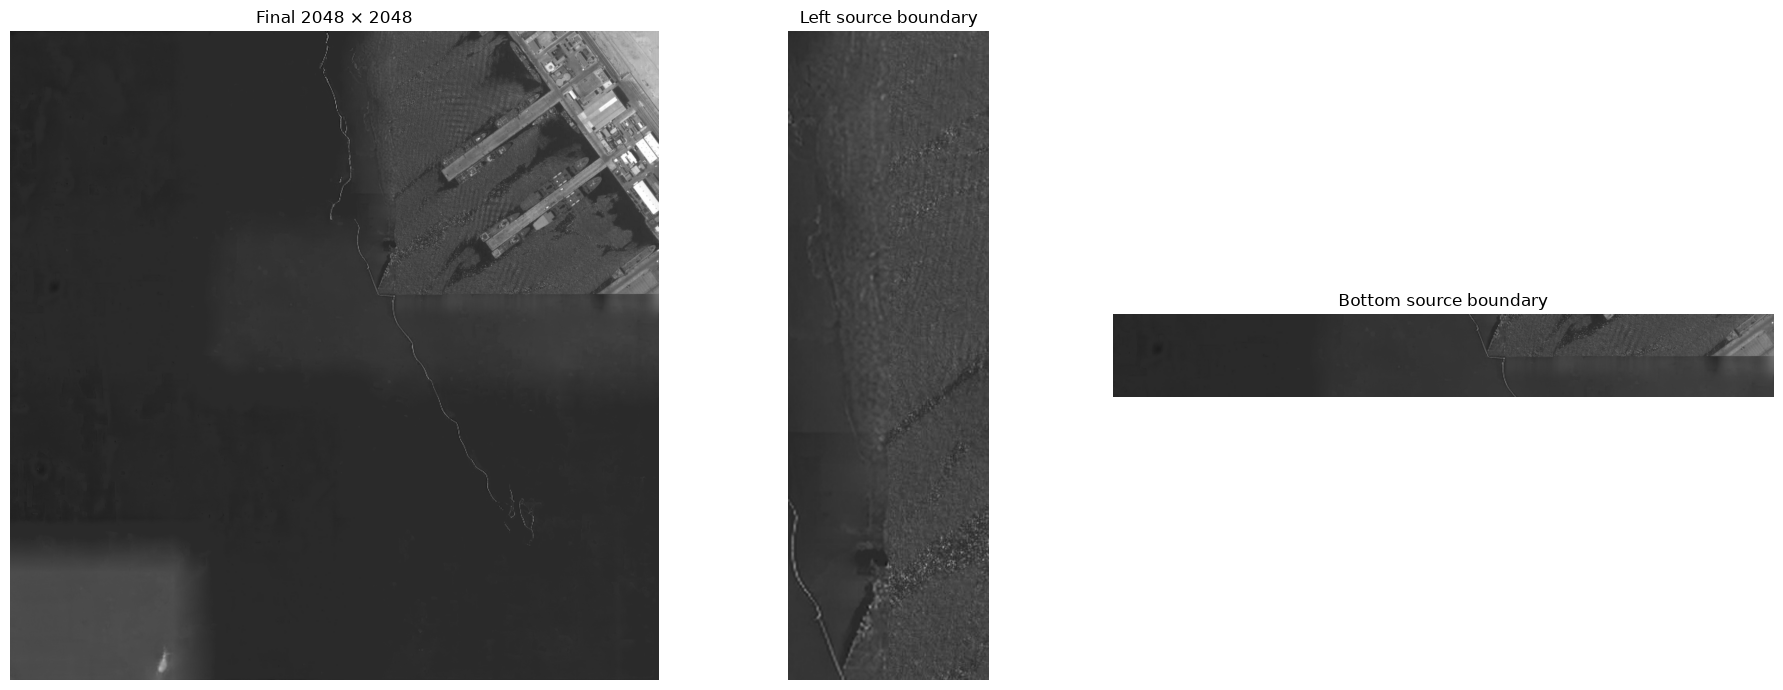

In [10]:
left_boundary = pilot_result.crop(
    (max(0, offset_x - 128), 0, min(CANVAS_SIZE, offset_x + 128), original_height)
)
bottom_boundary = pilot_result.crop(
    (0, max(0, original_height - 128), CANVAS_SIZE, min(CANVAS_SIZE, original_height + 128))
)

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
axes[0].imshow(pilot_result)
axes[0].set_title(f"Final {CANVAS_SIZE} × {CANVAS_SIZE}")
axes[1].imshow(left_boundary)
axes[1].set_title("Left source boundary")
axes[2].imshow(bottom_boundary)
axes[2].set_title("Bottom source boundary")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

## Stage 2 — semantic ring outpainting from 2048 to 10k

The approved scene grows as 2048 → 4096 → 6144 → 8192 → 10000. At every
stage, the entire previous scene is placed in the upper-right corner and is
strictly protected. One global guide defines the meaning of the new left and
bottom ring. Optional overlapping refinement contributes only fine residual
detail inside that new ring. The original source is restored and verified after
every stage.

In [11]:
# Ring-pipeline parameters
# Smaller late-stage rings keep the new area visible in the fixed-size guide.
STAGE_SIZES = [2048, 4096, 6144, 7168, 8192, 9216, 10000]

# Set to 6144 to resume from the last approved saved stage without recomputing
# 2048→4096→6144. Set to 2048 for a complete clean run.
RESUME_FROM_SIZE = 6144
RING_GUIDE_SIZE = 768
RING_GUIDE_STRENGTH = 0.86
RING_GUIDE_STEPS = 50

# Previous synthesis stays exact in its interior and is blended only near
# the old left/bottom ring boundary. Only the true source is immutable.
RING_TRANSITION_WIDTH = 384

RING_TILE_SIZE = 512
RING_TILE_OVERLAP = 256
RING_TILE_STEP = RING_TILE_SIZE - RING_TILE_OVERLAP
RING_REFINE_STRENGTH = 0.16
RING_REFINE_STEPS = 35

RING_DETAIL_BLUR_RADIUS = 18
RING_DETAIL_LIMIT = 8.0
RING_DETAIL_GAIN = 0.60

# False: fast semantic cascade for checking global composition.
# True: additionally refine each new ring with many 512px diffusion calls.
RUN_RING_DETAIL_REFINEMENT = False

RING_OUTPUT_DIR = PROJECT_ROOT / "data/test/ring_outpainting"
FINAL_10K_PATH = RING_OUTPUT_DIR / "ring_outpaint_final_10000x10000.png"

required_names = (
    "pilot_result", "original_image", "original_pixels",
    "original_width", "original_height", "scene_prompt", "negative_prompt", "pipe",
)
missing_names = [name for name in required_names if name not in globals()]
if missing_names:
    raise RuntimeError(
        "Run Stage 1 from the top first. Missing: " + ", ".join(missing_names)
    )
if RESUME_FROM_SIZE not in STAGE_SIZES:
    raise ValueError("RESUME_FROM_SIZE must be present in STAGE_SIZES")
if STAGE_SIZES[0] != CANVAS_SIZE:
    raise ValueError("STAGE_SIZES must begin with the Stage-1 CANVAS_SIZE")
if any(b <= a for a, b in zip(STAGE_SIZES, STAGE_SIZES[1:])):
    raise ValueError("STAGE_SIZES must be strictly increasing")
if any(size % 8 != 0 for size in STAGE_SIZES):
    raise ValueError("Every stage size must be divisible by 8")
if RING_GUIDE_SIZE % 8 != 0 or RING_TILE_STEP % 8 != 0:
    raise ValueError("Guide size and tile step must be divisible by 8")

RING_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Stages:", STAGE_SIZES)
print("Resume from:", RESUME_FROM_SIZE)
print("Detail refinement:", RUN_RING_DETAIL_REFINEMENT)

Stages: [2048, 4096, 6144, 7168, 8192, 9216, 10000]
Resume from: 6144
Detail refinement: False


In [12]:
def make_ring_scaffold(previous_image, next_size, seed, neutral_level=48):
    """Place the full previous scene upper-right on independent neutral exterior."""
    previous_size = previous_image.width
    if previous_image.size != (previous_size, previous_size):
        raise ValueError("Previous stage must be square")
    if next_size <= previous_size:
        raise ValueError("next_size must exceed previous_size")

    rng = np.random.default_rng(seed)
    coarse_size = max(8, next_size // 128)
    coarse = rng.normal(neutral_level, 3.0, (coarse_size, coarse_size))
    coarse = np.clip(coarse, 0, 255).astype(np.uint8)
    background = Image.fromarray(coarse, mode="L").resize(
        (next_size, next_size), Image.Resampling.BICUBIC
    ).filter(ImageFilter.GaussianBlur(8))
    scaffold = background.convert("RGB")

    previous_x = next_size - previous_size
    scaffold.paste(previous_image, (previous_x, 0))
    previous_box = (previous_x, 0, next_size, previous_size)
    return scaffold, previous_box


def make_new_ring_mask(size, previous_box):
    mask = Image.new("L", (size, size), 255)
    mask.paste(0, previous_box)
    return mask


def previous_stage_keep_mask(previous_size, transition_width):
    """Keep old pixels in the interior; fade them near left and bottom borders."""
    width = min(int(transition_width), previous_size // 3)
    y, x = np.mgrid[0:previous_size, 0:previous_size]
    distance_from_left = x.astype(np.float32)
    distance_from_bottom = (previous_size - 1 - y).astype(np.float32)
    distance = np.minimum(distance_from_left, distance_from_bottom)
    t = np.clip(distance / max(width, 1), 0.0, 1.0)
    # 0 at historical ring boundaries; 1 inside the protected old scene.
    alpha = 0.5 - 0.5 * np.cos(np.pi * t)
    return Image.fromarray(np.round(alpha * 255.0).astype(np.uint8), mode="L")


def generate_ring_global_guide(previous_image, next_size, stage_index):
    scaffold, previous_box = make_ring_scaffold(
        previous_image,
        next_size,
        seed=SEED + 40000 + stage_index,
        neutral_level=48,
    )
    source_box_at_stage = (
        next_size - original_width,
        0,
        next_size,
        original_height,
    )
    new_ring_mask = make_new_ring_mask(next_size, previous_box)

    guide_input = scaffold.resize(
        (RING_GUIDE_SIZE, RING_GUIDE_SIZE), Image.Resampling.LANCZOS
    )
    new_mask_small = new_ring_mask.resize(
        (RING_GUIDE_SIZE, RING_GUIDE_SIZE), Image.Resampling.NEAREST
    ).filter(ImageFilter.GaussianBlur(4))

    generator = torch.Generator(device="cpu").manual_seed(
        SEED + 41000 + stage_index
    )
    with torch.inference_mode():
        ring_small = pipe(
            prompt=scene_prompt,
            negative_prompt=negative_prompt,
            image=guide_input,
            mask_image=new_mask_small,
            width=RING_GUIDE_SIZE,
            height=RING_GUIDE_SIZE,
            strength=RING_GUIDE_STRENGTH,
            num_inference_steps=RING_GUIDE_STEPS,
            guidance_scale=GUIDANCE_SCALE,
            generator=generator,
        ).images[0].convert("L").convert("RGB")

    guide_large = ring_small.resize(
        (next_size, next_size), Image.Resampling.LANCZOS
    )

    # Preserve the previous scene exactly away from its historical boundaries.
    # Within RING_TRANSITION_WIDTH of the left/bottom border, blend it smoothly
    # with the new global guide so no immutable nested rectangle is created.
    previous_left, previous_top, previous_right, previous_bottom = previous_box
    guide_previous_region = guide_large.crop(previous_box)
    keep_mask = previous_stage_keep_mask(
        previous_image.width,
        RING_TRANSITION_WIDTH,
    )
    blended_previous = Image.composite(
        previous_image,
        guide_previous_region,
        keep_mask,
    )
    guide_large.paste(blended_previous, (previous_left, previous_top))

    # Real source remains exactly immutable after all blending.
    guide_large.paste(original_image, (source_box_at_stage[0], 0))
    return guide_large, new_ring_mask, previous_box, source_box_at_stage, ring_small

def ring_tile_boxes(size, tile_size, step, ring_mask):
    starts_x = tile_starts(size, tile_size, step)
    starts_y = tile_starts(size, tile_size, step)
    mask_array = np.asarray(ring_mask)
    boxes = []
    for top in starts_y:
        for left in starts_x:
            box = (left, top, left + tile_size, top + tile_size)
            if np.any(mask_array[top:top + tile_size, left:left + tile_size] > 0):
                boxes.append(box)
    return boxes

In [13]:
def refine_new_ring(global_guide, new_ring_mask, stage_index):
    """Add agreed high-frequency detail only within the newly generated ring."""
    size = global_guide.width
    boxes = ring_tile_boxes(
        size, RING_TILE_SIZE, RING_TILE_STEP, new_ring_mask
    )
    window = cosine_window(RING_TILE_SIZE)[..., None]
    detail_sum = np.zeros((size, size, 3), dtype=np.float32)
    detail_square_sum = np.zeros((size, size, 3), dtype=np.float32)
    weight_sum = np.zeros((size, size, 1), dtype=np.float32)

    print(f"Ring refinement: {len(boxes)} tiles")
    for tile_index, (left, top, right, bottom) in enumerate(boxes):
        print(f"  [{tile_index + 1}/{len(boxes)}]", (left, top, right, bottom))
        tile_guide = global_guide.crop((left, top, right, bottom)).convert("RGB")
        exact_mask = new_ring_mask.crop((left, top, right, bottom)).convert("L")
        mask_array = np.asarray(exact_mask, dtype=np.uint8)
        if not np.any(mask_array > 0):
            continue
        model_mask = exact_mask.filter(ImageFilter.GaussianBlur(8))
        tile_seed = (
            SEED + 50000 + stage_index * 10000
            + (top // 8) * (size // 8) + left // 8
        )
        generator = torch.Generator(device="cpu").manual_seed(tile_seed)

        with torch.inference_mode():
            prediction = pipe(
                prompt=scene_prompt,
                negative_prompt=negative_prompt,
                image=tile_guide,
                mask_image=model_mask,
                width=RING_TILE_SIZE,
                height=RING_TILE_SIZE,
                strength=RING_REFINE_STRENGTH,
                num_inference_steps=RING_REFINE_STEPS,
                guidance_scale=GUIDANCE_SCALE,
                generator=generator,
            ).images[0].convert("L").convert("RGB")

        prediction_array = np.asarray(prediction).astype(np.float32)
        prediction_low = np.asarray(
            prediction.filter(ImageFilter.GaussianBlur(RING_DETAIL_BLUR_RADIUS))
        ).astype(np.float32)
        detail = np.clip(
            prediction_array - prediction_low,
            -RING_DETAIL_LIMIT,
            RING_DETAIL_LIMIT,
        )
        exterior = (mask_array.astype(np.float32) / 255.0)[..., None]
        weights = window * exterior
        detail_sum[top:bottom, left:right] += detail * weights
        detail_square_sum[top:bottom, left:right] += detail ** 2 * weights
        weight_sum[top:bottom, left:right] += weights

    guide_array = np.asarray(global_guide).astype(np.float32)
    output = guide_array.copy()
    valid = weight_sum[..., 0] > 1e-6
    detail_mean = np.zeros_like(detail_sum)
    detail_square_mean = np.zeros_like(detail_square_sum)
    detail_mean[valid] = detail_sum[valid] / weight_sum[valid]
    detail_square_mean[valid] = detail_square_sum[valid] / weight_sum[valid]
    variance = np.maximum(detail_square_mean - detail_mean ** 2, 0.0)
    disagreement = np.mean(variance, axis=2)
    confidence = np.clip(np.exp(-disagreement / 24.0), 0.25, 1.0)
    output[valid] = (
        guide_array[valid]
        + detail_mean[valid] * confidence[valid, None] * RING_DETAIL_GAIN
    )
    return Image.fromarray(np.clip(output, 0, 255).astype(np.uint8), mode="RGB")

In [14]:
# Execute or resume the semantic cascade. The real source is immutable;
# the previous synthetic stage fades only across its left/bottom boundary band.
if RESUME_FROM_SIZE == STAGE_SIZES[0]:
    current_stage = pilot_result.copy().convert("RGB")
else:
    resume_path = RING_OUTPUT_DIR / (
        f"ring_stage_{RESUME_FROM_SIZE}x{RESUME_FROM_SIZE}.png"
    )
    if not resume_path.is_file():
        raise FileNotFoundError(
            f"Approved resume stage is missing: {resume_path}"
        )
    with Image.open(resume_path) as resume_source:
        current_stage = resume_source.convert("RGB").copy()
    print("Loaded approved stage:", resume_path)

if current_stage.size != (RESUME_FROM_SIZE, RESUME_FROM_SIZE):
    raise ValueError(
        f"Resume image is {current_stage.size}, expected "
        f"{(RESUME_FROM_SIZE, RESUME_FROM_SIZE)}"
    )

resume_index = STAGE_SIZES.index(RESUME_FROM_SIZE)
remaining_sizes = STAGE_SIZES[resume_index + 1:]
stage_records = []

for local_index, next_size in enumerate(remaining_sizes, start=1):
    stage_index = resume_index + local_index
    previous_stage = current_stage.copy()
    previous_pixels = np.asarray(previous_stage).copy()
    previous_size = previous_stage.width
    previous_x = next_size - previous_size

    print()
    print(f"Stage {previous_size} -> {next_size}")
    (
        global_ring_guide,
        new_ring_mask,
        previous_box,
        source_box_at_stage,
        guide_small,
    ) = generate_ring_global_guide(
        previous_stage,
        next_size,
        stage_index,
    )

    if RUN_RING_DETAIL_REFINEMENT:
        current_stage = refine_new_ring(
            global_ring_guide,
            new_ring_mask,
            stage_index,
        )
    else:
        current_stage = global_ring_guide.copy()

    # Restore the true source after every operation. It is never blended.
    source_x_at_stage = next_size - original_width
    current_stage.paste(original_image, (source_x_at_stage, 0))

    restored_original = np.asarray(
        current_stage.crop(source_box_at_stage)
    )
    assert np.array_equal(
        restored_original,
        original_pixels,
    ), f"Original pixels changed at {next_size}px stage"

    stage_path = RING_OUTPUT_DIR / f"ring_stage_{next_size}x{next_size}.png"
    current_stage.save(stage_path, format="PNG", compress_level=2)
    stage_records.append(
        {
            "size": next_size,
            "path": stage_path,
            "guide_small": guide_small,
            "previous_box": previous_box,
        }
    )

    preview = current_stage.resize((768, 768), Image.Resampling.LANCZOS)
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(guide_small)
    axes[0].set_title(f"Global ring guide: {previous_size} → {next_size}")
    axes[1].imshow(preview)
    axes[1].set_title(f"Protected stage {next_size} × {next_size}")
    for axis in axes:
        axis.axis("off")
    plt.tight_layout()
    plt.show()

    print("Saved:", stage_path)
    print("Original pixels unchanged: True")

current_stage.save(FINAL_10K_PATH, format="PNG", compress_level=2)
final_10k = current_stage
print()
print("Final 10k saved:", FINAL_10K_PATH)

FileNotFoundError: Approved resume stage is missing: /home/irdorat/ML_comp/data/test/ring_outpainting/ring_stage_6144x6144.png

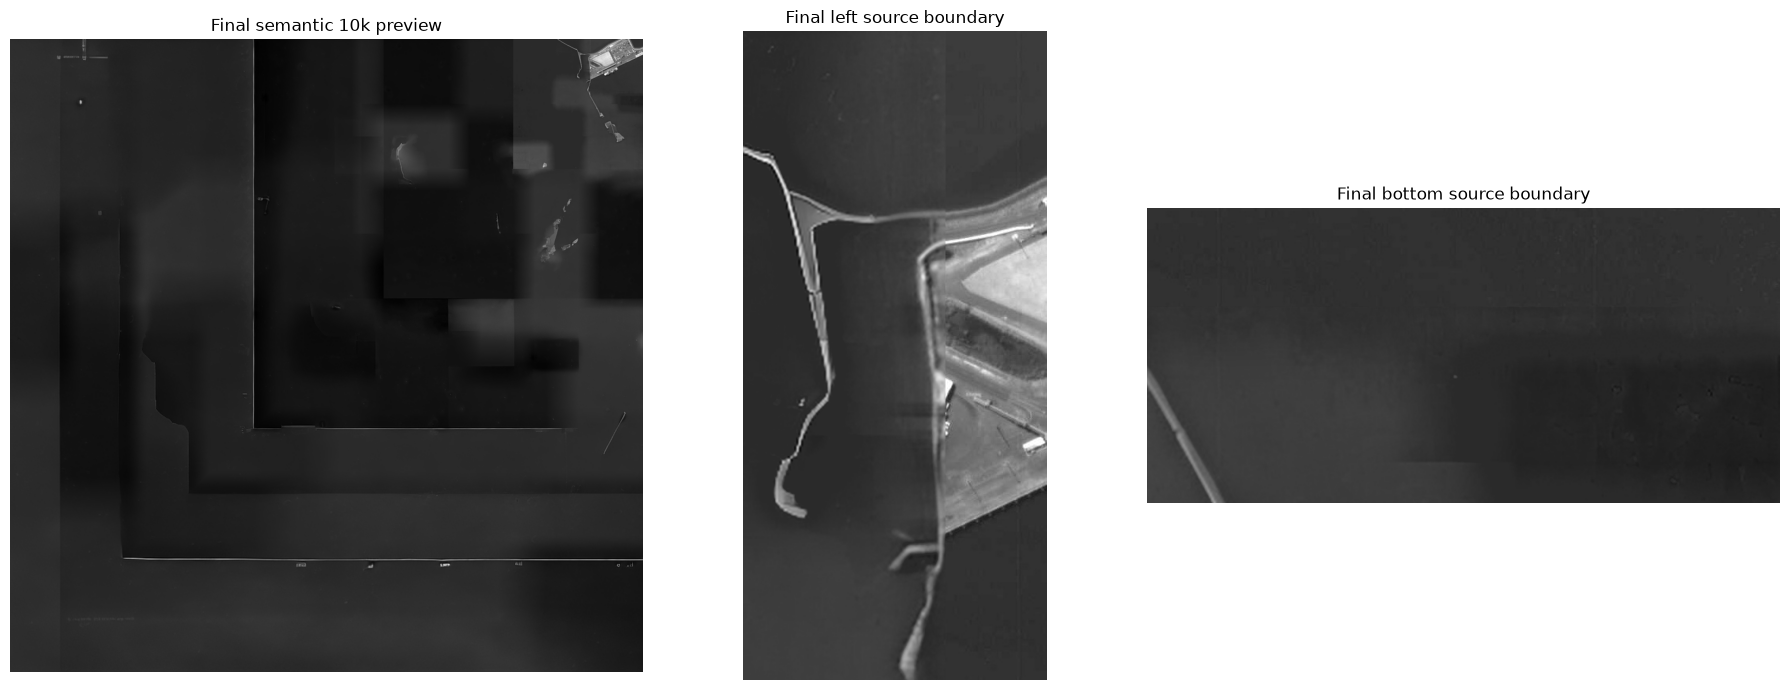

In [ ]:
final_preview = final_10k.resize((1000, 1000), Image.Resampling.LANCZOS)
source_x_10k = final_10k.width - original_width
left_source_boundary_10k = final_10k.crop(
    (
        max(0, source_x_10k - 256),
        0,
        min(final_10k.width, source_x_10k + 128),
        original_height,
    )
)
bottom_source_boundary_10k = final_10k.crop(
    (
        source_x_10k,
        max(0, original_height - 128),
        final_10k.width,
        min(final_10k.height, original_height + 256),
    )
)

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
axes[0].imshow(final_preview)
axes[0].set_title("Final semantic 10k preview")
axes[1].imshow(left_source_boundary_10k)
axes[1].set_title("Final left source boundary")
axes[2].imshow(bottom_source_boundary_10k)
axes[2].set_title("Final bottom source boundary")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()

## Stage 3 — final 10k harmonization and ring-seam repair

First, one reduced global pass estimates only low-frequency illumination changes.
Then narrow bands around every historical ring boundary are inpainted with
overlapping 512px windows. Only those bands may change. The true source crop is
excluded from every write mask and restored exactly at the end.

In [ ]:
# Final repair controls
RUN_FINAL_LOW_FREQUENCY_HARMONIZATION = False
RUN_FINAL_SEAM_INPAINT = False

FINAL_GLOBAL_SIZE = 768
FINAL_GLOBAL_STRENGTH = 0.16
FINAL_GLOBAL_STEPS = 35
FINAL_RESIDUAL_LIMIT = 8.0
FINAL_RESIDUAL_BLUR = 18
HARMONIZE_STRIPE_HEIGHT = 256

SEAM_HALF_WIDTH = 96
SEAM_TILE_SIZE = 512
SEAM_TILE_STEP = 384
SEAM_STRENGTH = 0.22
SEAM_STEPS = 35
SEAM_GUIDANCE = 3.5
SEAM_FEATHER = 32

HARMONIZED_10K_PATH = RING_OUTPUT_DIR / "ring_outpaint_10k_harmonized.png"
SEAM_REPAIRED_10K_PATH = RING_OUTPUT_DIR / "ring_outpaint_10k_seam_repaired.png"

if final_10k.size != (10000, 10000):
    raise ValueError(f"Expected final 10k image, received {final_10k.size}")
if SEAM_TILE_SIZE % 8 != 0 or SEAM_TILE_STEP % 8 != 0:
    raise ValueError("Seam tile size and step must be divisible by 8")

# Historical protected-stage borders as embedded in the final 10k coordinates.
RING_BOUNDARY_SIZES = STAGE_SIZES[:-1]
print("Ring boundaries to repair:", RING_BOUNDARY_SIZES)

Ring boundaries to repair: [2048, 4096, 6144, 7168, 8192, 9216]


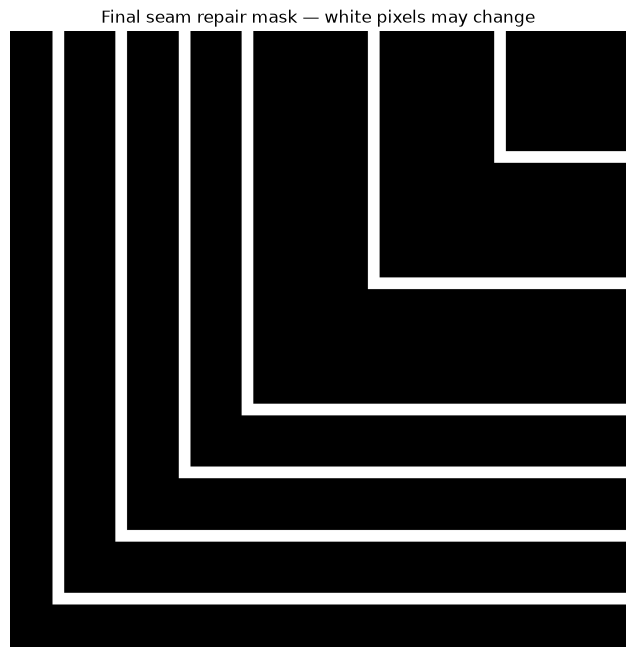

In [ ]:
def restore_true_source(image):
    source_x = image.width - original_width
    image.paste(original_image, (source_x, 0))
    return image


def assert_true_source_unchanged(image):
    source_x = image.width - original_width
    restored = np.asarray(
        image.crop((source_x, 0, image.width, original_height))
    )
    assert np.array_equal(restored, original_pixels), "True source pixels changed"


def make_all_ring_seam_mask(final_size, boundary_sizes, half_width):
    """Create L-shaped bands around every earlier upper-right protected stage."""
    mask = Image.new("L", (final_size, final_size), 0)
    source_x = final_size - original_width

    for protected_size in boundary_sizes:
        left = final_size - protected_size
        bottom = protected_size

        # Vertical boundary at the left side of the historical protected square.
        mask.paste(
            255,
            (
                max(0, left - half_width),
                0,
                min(final_size, left + half_width),
                min(final_size, bottom + half_width),
            ),
        )

        # Horizontal boundary below the historical protected square.
        mask.paste(
            255,
            (
                max(0, left - half_width),
                max(0, bottom - half_width),
                final_size,
                min(final_size, bottom + half_width),
            ),
        )

    # The true source is immutable, even where a seam band approaches it.
    mask.paste(0, (source_x, 0, final_size, original_height))
    return mask


all_seam_mask = make_all_ring_seam_mask(
    10000,
    RING_BOUNDARY_SIZES,
    SEAM_HALF_WIDTH,
)

preview_mask = all_seam_mask.resize((1000, 1000), Image.Resampling.NEAREST)
plt.figure(figsize=(8, 8))
plt.imshow(preview_mask, cmap="gray", vmin=0, vmax=255)
plt.title("Final seam repair mask — white pixels may change")
plt.axis("off")
plt.show()

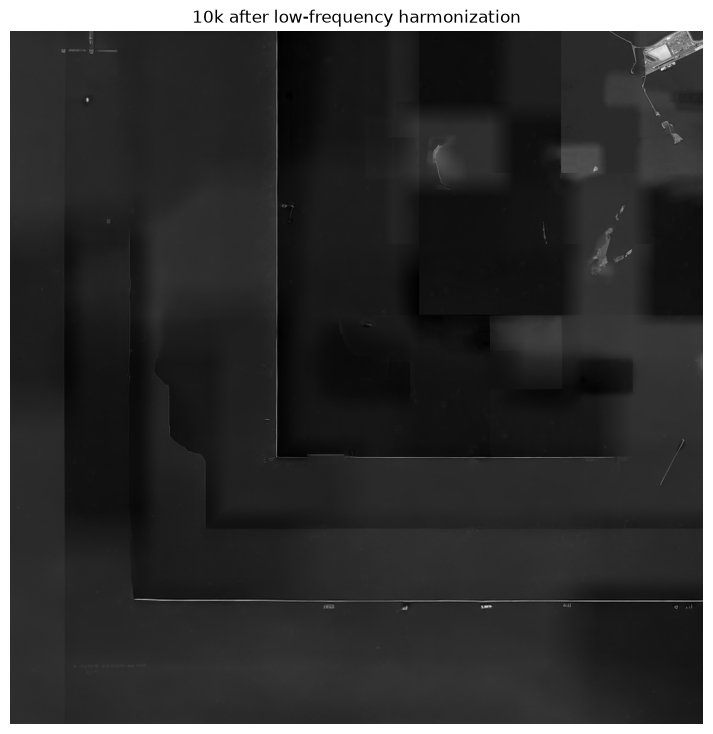

Saved: /home/irdorat/ML_comp/data/test/ring_outpainting/ring_outpaint_10k_harmonized.png


In [ ]:
# One global pass estimates coherent low-frequency exposure only.
if RUN_FINAL_LOW_FREQUENCY_HARMONIZATION:
    global_input = final_10k.resize(
        (FINAL_GLOBAL_SIZE, FINAL_GLOBAL_SIZE),
        Image.Resampling.LANCZOS,
    )

    scale = FINAL_GLOBAL_SIZE / final_10k.width
    source_small_box = (
        int(round((final_10k.width - original_width) * scale)),
        0,
        FINAL_GLOBAL_SIZE,
        int(round(original_height * scale)),
    )
    global_mask = Image.new("L", (FINAL_GLOBAL_SIZE, FINAL_GLOBAL_SIZE), 255)
    global_mask.paste(0, source_small_box)
    global_model_mask = global_mask.filter(ImageFilter.GaussianBlur(6))
    generator = torch.Generator(device="cpu").manual_seed(SEED + 70000)

    with torch.inference_mode():
        global_prediction = pipe(
            prompt=scene_prompt,
            negative_prompt=negative_prompt,
            image=global_input,
            mask_image=global_model_mask,
            width=FINAL_GLOBAL_SIZE,
            height=FINAL_GLOBAL_SIZE,
            strength=FINAL_GLOBAL_STRENGTH,
            num_inference_steps=FINAL_GLOBAL_STEPS,
            guidance_scale=3.5,
            generator=generator,
        ).images[0].convert("L")

    base_small = np.asarray(global_input.convert("L")).astype(np.float32)
    prediction_small = np.asarray(global_prediction).astype(np.float32)
    residual = np.clip(
        prediction_small - base_small,
        -FINAL_RESIDUAL_LIMIT,
        FINAL_RESIDUAL_LIMIT,
    )
    residual_encoded = Image.fromarray(
        np.clip(residual + 128.0, 0, 255).astype(np.uint8),
        mode="L",
    ).filter(ImageFilter.GaussianBlur(FINAL_RESIDUAL_BLUR))
    # Keep the upscaled residual as an 8-bit PIL image (~100 MB), then process
    # the RGB scene in narrow stripes. Never allocate a 10k RGB float32 array.
    residual_large_image = residual_encoded.resize(
        final_10k.size,
        Image.Resampling.BICUBIC,
    )
    harmonized_10k = final_10k.copy().convert("RGB")

    for stripe_top in range(0, final_10k.height, HARMONIZE_STRIPE_HEIGHT):
        stripe_bottom = min(
            final_10k.height,
            stripe_top + HARMONIZE_STRIPE_HEIGHT,
        )
        stripe_box = (0, stripe_top, final_10k.width, stripe_bottom)
        image_stripe = np.asarray(
            final_10k.crop(stripe_box), dtype=np.int16
        ).copy()
        residual_stripe = np.asarray(
            residual_large_image.crop(stripe_box), dtype=np.int16
        ) - 128
        image_stripe += residual_stripe[..., None]
        image_stripe = np.clip(image_stripe, 0, 255).astype(np.uint8)
        harmonized_10k.paste(
            Image.fromarray(image_stripe, mode="RGB"),
            (0, stripe_top),
        )
        print(f"Harmonization rows: {stripe_bottom}/{final_10k.height}")

    del residual_large_image
    restore_true_source(harmonized_10k)
else:
    harmonized_10k = final_10k.copy()

assert_true_source_unchanged(harmonized_10k)
harmonized_10k.save(HARMONIZED_10K_PATH, format="PNG", compress_level=2)

plt.figure(figsize=(9, 9))
plt.imshow(harmonized_10k.resize((1000, 1000), Image.Resampling.LANCZOS))
plt.title("10k after low-frequency harmonization")
plt.axis("off")
plt.show()
print("Saved:", HARMONIZED_10K_PATH)

In [ ]:
def seam_tile_boxes(mask, tile_size, step):
    xs = tile_starts(mask.width, tile_size, step)
    ys = tile_starts(mask.height, tile_size, step)
    boxes = []
    for top in ys:
        for left in xs:
            box = (left, top, left + tile_size, top + tile_size)
            # getbbox() checks only the small crop and avoids a 100 MB mask array.
            if mask.crop(box).getbbox() is not None:
                boxes.append(box)
    return boxes


def repair_seams(image, seam_mask):
    """Sequentially repair seam bands; exact writes never leave the seam mask."""
    result = image.copy().convert("RGB")
    boxes = seam_tile_boxes(seam_mask, SEAM_TILE_SIZE, SEAM_TILE_STEP)
    print("Seam tiles:", len(boxes))

    for tile_index, box in enumerate(boxes):
        left, top, right, bottom = box
        print(f"[{tile_index + 1}/{len(boxes)}]", box)
        tile = result.crop(box).convert("RGB")
        exact_mask = seam_mask.crop(box).convert("L")
        exact_array = np.asarray(exact_mask, dtype=np.uint8)
        if not np.any(exact_array > 0):
            continue

        model_mask = exact_mask.filter(ImageFilter.GaussianBlur(10))
        tile_seed = SEED + 80000 + (top // 8) * 1250 + left // 8
        generator = torch.Generator(device="cpu").manual_seed(tile_seed)

        with torch.inference_mode():
            prediction = pipe(
                prompt=scene_prompt,
                negative_prompt=negative_prompt,
                image=tile,
                mask_image=model_mask,
                width=SEAM_TILE_SIZE,
                height=SEAM_TILE_SIZE,
                strength=SEAM_STRENGTH,
                num_inference_steps=SEAM_STEPS,
                guidance_scale=SEAM_GUIDANCE,
                generator=generator,
            ).images[0].convert("L").convert("RGB")

        # Feather inside the allowed band, but never write outside its binary mask.
        feather = exact_mask.filter(ImageFilter.GaussianBlur(SEAM_FEATHER))
        feather_array = np.asarray(feather, dtype=np.float32)
        feather_array *= (exact_array > 0)
        feather_mask = Image.fromarray(
            np.clip(feather_array, 0, 255).astype(np.uint8), mode="L"
        )
        composed = Image.composite(prediction, tile, feather_mask)
        result.paste(composed, (left, top))

        # Protect the true source after every tile, not only at the end.
        restore_true_source(result)

        if (tile_index + 1) % 50 == 0:
            checkpoint = RING_OUTPUT_DIR / f"seam_checkpoint_{tile_index + 1:04d}.png"
            result.save(checkpoint, format="PNG", compress_level=2)
            print("Checkpoint:", checkpoint)

    return result


if RUN_FINAL_SEAM_INPAINT:
    seam_repaired_10k = repair_seams(harmonized_10k, all_seam_mask)
else:
    seam_repaired_10k = harmonized_10k.copy()

restore_true_source(seam_repaired_10k)
assert_true_source_unchanged(seam_repaired_10k)
seam_repaired_10k.save(SEAM_REPAIRED_10K_PATH, format="PNG", compress_level=2)
print("Saved:", SEAM_REPAIRED_10K_PATH)
print("True source unchanged: True")

Saved: /home/irdorat/ML_comp/data/test/ring_outpainting/ring_outpaint_10k_seam_repaired.png
True source unchanged: True


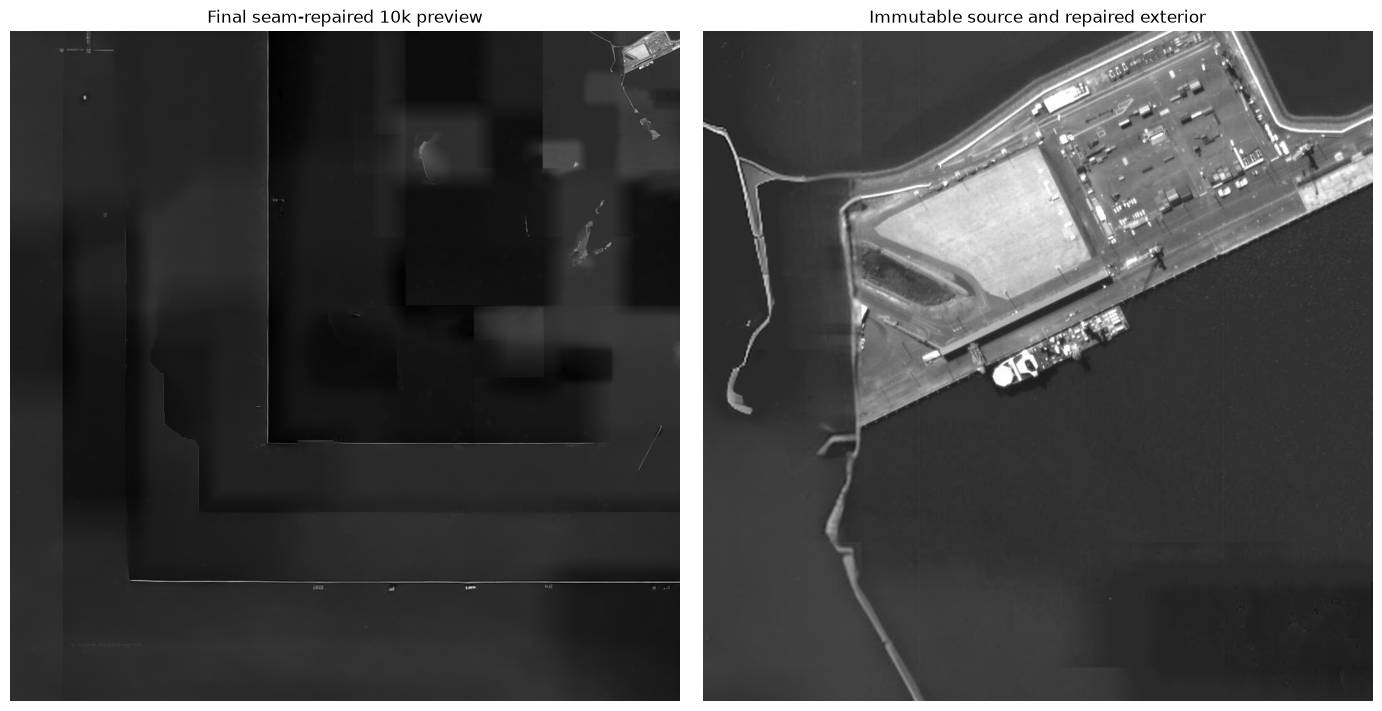

In [ ]:
repaired_preview = seam_repaired_10k.resize(
    (1000, 1000), Image.Resampling.LANCZOS
)
source_x_final = seam_repaired_10k.width - original_width
source_boundary_crop = seam_repaired_10k.crop(
    (
        max(0, source_x_final - 256),
        0,
        seam_repaired_10k.width,
        min(seam_repaired_10k.height, original_height + 256),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(repaired_preview)
axes[0].set_title("Final seam-repaired 10k preview")
axes[1].imshow(source_boundary_crop)
axes[1].set_title("Immutable source and repaired exterior")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()